In [117]:
# ---------------------------------------------------------------------
# Project: Prediction of autoreactive TCRs using machine learning
# This notebook builds a classification pipeline to distinguish
# T-cell receptors associated with autoimmune responses from those
# associated with viral antigens.
# 
# General workflow:
# 1. Load TCR datasets from VDJdb and McPAS.
# 2. Clean and preprocess CDR3 sequences.
# 3. Construct paired alpha:beta TCR representations.
# 4. Build a labeled dataset (virus = control, autoimmune = positive).
# 5. Generate protein language model embeddings (ESM).
# 6. Train and compare machine learning classifiers.
# 7. Evaluate generalization and biological interpretability.
# 
# Biological background:
# Autoreactive TCRs are capable of recognizing self-peptides presented
# by MHC molecules. Identifying sequence features that distinguish them
# from pathogen-specific TCRs could help understand autoimmune diseases
# such as Type 1 Diabetes.
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [118]:
# ---------------------------------------------------------------------
# Data loading step
# 
# Here we import datasets containing TCR sequences associated with
# different antigen specificities.
# 
# VDJdb:
# A curated database of TCR sequences with known antigen specificity.
# 
# McPAS-TCR:
# A manually curated catalog of pathology-associated TCR sequences,
# including autoimmune diseases.
# 
# The goal is to combine these sources to obtain a broader and more
# diverse repertoire of autoreactive TCRs.
# ---------------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
# ---------------------------------------------------------------------
# Dataset inspection
# 
# At this stage we examine the structure of the datasets to understand:
# - number of sequences
# - available metadata
# - gene chain (TRA or TRB)
# - CDR3 amino acid sequences
# 
# The CDR3 region is the most variable region of the TCR and largely
# determines antigen specificity. Therefore it is the key feature used
# in this project.
# ---------------------------------------------------------------------

path_virus_tcr ='/content/drive/MyDrive/TCR_autoimmune/data/VDJdb_virus.tsv'

In [120]:
path_auto_tcr ='/content/drive/MyDrive/TCR_autoimmune/data/VDJdb_autoimmune.tsv'

In [121]:
path_auto_tcr_mcPAS='/content/drive/MyDrive/TCR_autoimmune/data/McPAS-TCR_search.csv'

In [122]:
df_virus = pd.read_csv(path_virus_tcr, sep='\t')

In [123]:
df_auto = pd.read_csv(path_auto_tcr, sep='\t')

In [124]:
df_virus.head()

,complex.id,Gene,CDR3,V,J,Species,MHC A,MHC B,MHC class,Epitope,Epitope gene,Epitope species,Reference,Method,Meta,CDR3fix,Score
0,1,TRA,CAYRSAGSGGSNYKLTF,TRAV38-2/DV8*01,TRAJ53*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CAYRSAGSGGSNYKLTF"", ""cdr3_old"": ""CAY...",3
1,1,TRB,CASSLMTNQPQHF,TRBV27*01,TRBJ1-5*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CASSLMTNQPQHF"", ""cdr3_old"": ""CASSLMT...",3
2,2,TRA,CAYRSATGYALNF,TRAV38-2/DV8*01,TRAJ41*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CAYRSATGYALNF"", ""cdr3_old"": ""CAYRSAT...",3
3,2,TRB,CASSLYGSVQNEQFF,TRBV27*01,TRBJ2-1*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CASSLYGSVQNEQFF"", ""cdr3_old"": ""CASSL...",3
4,3,TRA,CALSEYSGGYQKVTF,TRAV19*01,TRAJ13*01,HomoSapiens,HLA-B*07:02,B2M,MHCI,HPNGYKSLSTL,NS1,InfluenzaB,PMID:38684663,"{""identification"": ""tetramer.sort"", ""frequency...","{""study.id"": ""B7+B8+"", ""cell.subset"": ""CD8+"", ...","{""cdr3"": ""CALSEYSGGYQKVTF"", ""cdr3_old"": ""CALSE...",3


In [125]:
df_auto.head()

,complex.id,Gene,CDR3,V,J,Species,MHC A,MHC B,MHC class,Epitope,Epitope gene,Epitope species,Reference,Method,Meta,CDR3fix,Score
0,171,TRA,CAVQAGGNNRLAF,TRAV20*01,TRAJ7*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CAVQAGGNNRLAF"", ""cdr3_old"": ""CAVQAGG...",0
1,171,TRB,CASSLERDGYTF,TRBV5-1*01,TRBJ1-2*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CASSLERDGYTF"", ""cdr3_old"": ""CASSLERD...",0
2,172,TRA,CIAIYNFNKFYF,TRAV26-1*01,TRAJ21*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CIAIYNFNKFYF"", ""cdr3_old"": ""CIAIYNFN...",0
3,172,TRB,CASSLEASSYNSPLHF,TRBV5-1*01,TRBJ1-6*02,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CASSLEASSYNSPLHF"", ""cdr3_old"": ""CASS...",0
4,173,TRA,CIVSHNAGNMLTF,TRAV26-1*01,TRAJ39*01,HomoSapiens,HLA-DQA1*03:01,HLA-DQB1*02:01,MHCII,VELGGGPGA,INS,HomoSapiens,PMID:25157096,"{""identification"": ""antigen-expressing-targets...","{""study.id"": """", ""cell.subset"": """", ""subject.c...","{""cdr3"": ""CIVSHNAGNMLTF"", ""cdr3_old"": ""CIVSHNA...",0


In [126]:
is_auto = df_auto['Epitope gene'].str.contains('Insulin|GAD|IA-2|ZnT8', case=False, na=False)
df_auto_strict = df_auto[is_auto].copy()

is_virus = df_virus['Epitope species'].str.contains('Influenza|CMV|EBV|SARS|HIV', case=False, na=False)
df_virus_strict = df_virus[is_virus].copy()

comunes = set(df_virus_strict['CDR3']) & set(df_auto_strict['CDR3'])

df_virus_final = df_virus_strict[~df_virus_strict['CDR3'].isin(comunes)].copy()
df_auto_final = df_auto_strict.copy()

print(f" virus: {len(df_virus_final)}")
print(f"T1D: {len(df_auto_final)}")

 virus: 12070
T1D: 434


In [127]:

df_virus_balanced = df_virus_final.sample(n=len(df_auto_final), random_state=42)
df_auto_balanced = df_auto_final.copy()



In [128]:
!pip install transformers torch scikit-learn

In [129]:
def prepare_paired_sequences(df, label):
    # Combined column
    df['esm_input'] = df['CDR3_alpha'] + ":" + df['CDR3_beta']
    return df[['esm_input']].assign(label=label)

In [130]:
import pandas as pd
import numpy as np
def brute_force_pairing(df_virus, df_auto):
    def get_sequential_pairs(df, label):
        # Extraer todas las secuencias limpias
        alphas = df[df['Gene'].str.contains('TRA', na=False)]['CDR3'].tolist()
        betas = df[df['Gene'].str.contains('TRB', na=False)]['CDR3'].tolist()

        # Emparejar por posición hasta que se acabe el más corto
        min_len = min(len(alphas), len(betas))
        paired_seqs = [f"{alphas[i]}:{betas[i]}" for i in range(min_len)]

        return pd.DataFrame({'esm_input': paired_seqs, 'label': label})

    # Generar pares para ambos bandos
    df_v = get_sequential_pairs(df_virus, 0)
    df_a = get_sequential_pairs(df_auto, 1)

    # Unir y balancear para que el modelo no haga trampas
    min_samples = min(len(df_v), len(df_a))
    df_final = pd.concat([
        df_v.sample(min_samples, random_state=42),
        df_a.sample(min_samples, random_state=42)
    ]).sample(frac=1).reset_index(drop=True)

    print(f"Dataset listo con {len(df_final)} pares totales.")
    print(df_final['label'].value_counts())
    return df_final

In [131]:
import pandas as pd
import numpy as np

def prepare_balanced_data_brute_force(df_virus, df_auto, n_pairs=200):
    """
    Empareja TRA y TRB por fuerza bruta (índice) manteniendo el nombre del antígeno.
    """
    # 1. Preparar Diabetes (Clase 1)
    # Filtramos por los genes sospechosos en T1D
    is_auto = df_auto['Epitope gene'].str.contains('Insulin|GAD|IA-2|ZnT8|INS', case=False, na=False)
    df_a_sub = df_auto[is_auto].copy()

    # Separar Alphas y Betas manteniendo el orden
    a_alphas = df_a_sub[df_a_sub['Gene'] == 'TRA'].reset_index(drop=True)
    a_betas = df_a_sub[df_a_sub['Gene'] == 'TRB'].reset_index(drop=True)

    # Determinamos el número real de pares posibles
    limit_a = min(len(a_alphas), len(a_betas), n_pairs)

    df_a_final = pd.DataFrame({
        'esm_input': a_alphas['CDR3'].iloc[:limit_a].values + ":" + a_betas['CDR3'].iloc[:limit_a].values,
        'Epitope gene': a_alphas['Epitope gene'].iloc[:limit_a].values,
        'label': 1
    })

    # 2. Preparar Virus (Clase 0)
    v_alphas = df_virus[df_virus['Gene'] == 'TRA'].reset_index(drop=True)
    v_betas = df_virus[df_virus['Gene'] == 'TRB'].reset_index(drop=True)

    limit_v = min(len(v_alphas), len(v_betas), n_pairs)

    df_v_final = pd.DataFrame({
        'esm_input': v_alphas['CDR3'].iloc[:limit_v].values + ":" + v_betas['CDR3'].iloc[:limit_v].values,
        'Epitope gene': 'Virus',
        'label': 0
    })

    # 3. Concatenar y resetear índice para que coincida con X
    df_final = pd.concat([df_a_final, df_v_final]).reset_index(drop=True)
    print(f"Dataset listo con {len(df_final)} pares totales.")
    print(df_final['label'].value_counts())

    return df_final


In [132]:
from transformers import AutoTokenizer, EsmModel
import torch
from tqdm import tqdm

def extract_esm_embeddings(sequences, model_name="facebook/esm2_t6_8M_UR50D", batch_size=32):
    """Convierte secuencias en vectores detectando automáticamente GPU/CPU."""
    # Detectar dispositivo
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" usando dispositivo: {device}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = EsmModel.from_pretrained(model_name).to(device).eval()

    embeddings_list = []

    for i in tqdm(range(0, len(sequences), batch_size), desc="Extrayendo Embeddings"):
        batch = sequences[i : i + batch_size]

        # Enviamos los tokens al dispositivo detectado
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Pasamos a CPU para convertir a numpy
            batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings_list.append(batch_emb)

    return np.vstack(embeddings_list)

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

def train_and_evaluate(X, y):
    """Entrena un Random Forest y muestra métricas de rendimiento."""
    # Dividir con 'stratify' para mantener la proporción de virus/auto
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # Usamos class_weight='balanced' por el desbalanceo que tienes
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1)
    clf.fit(X_train, y_train)

    probs = clf.predict_proba(X_test)[:, 1]
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_test, clf.predict(X_test)))
    print(f"AUC-ROC Score: {roc_auc_score(y_test, probs):.4f}")

    return clf, y_test, probs

In [134]:
df_final = prepare_balanced_data_brute_force(df_virus_balanced, df_auto_balanced)


Dataset listo con 400 pares totales.
label
1    200
0    200
Name: count, dtype: int64


In [135]:

sequences = df_final['esm_input'].tolist()
y = df_final['label'].values

In [136]:
X = extract_esm_embeddings(sequences)

 usando dispositivo: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extrayendo Embeddings: 100%|██████████| 13/13 [00:01<00:00,  8.67it/s]


In [137]:
clf_tcr, y_test, probs = train_and_evaluate(X, y)



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.74      0.65      0.69        40
           1       0.69      0.78      0.73        40

    accuracy                           0.71        80
   macro avg       0.72      0.71      0.71        80
weighted avg       0.72      0.71      0.71        80

AUC-ROC Score: 0.7538


In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def big_model_battle(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
        "SVM (RBF)": Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, class_weight='balanced'))]),
        "Logit (Normal)": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
        "Logit (LASSO L1)": Pipeline([('scaler', StandardScaler()), ('lasso', LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced'))]),
        "XGBoost": XGBClassifier( eval_metric='logloss')
    }

    print("MODEL BATTLE\n")
    results = {}
    best_auc = -1
    best_clf = None
    best_scaler = None

    for name, clf in models.items():
        clf.fit(X_train, y_train)
        probs = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probs)
        results[name] = auc

        if auc > best_auc:
            best_auc = auc
            best_clf = clf
            if isinstance(clf, Pipeline) and 'scaler' in clf.named_steps:
                best_scaler = clf.named_steps['scaler']
            else:
                best_scaler = None # Or handle other cases if a scaler isn't always part of the pipeline

        # Extraer info extra de LASSO
        if name == "Logit (LASSO L1)":
            n_features = np.sum(clf.named_steps['lasso'].coef_ != 0)
            print(f"{name:20} -> AUC: {auc:.4f} (Usó {n_features} dimensiones)")
        else:
            print(f"{name:20} -> AUC: {auc:.4f}")

    return results, best_clf, best_scaler

# Ejecutar
resultados_finales, best_clf, scaler = big_model_battle(X, y)

MODEL BATTLE

Random Forest        -> AUC: 0.7609
SVM (RBF)            -> AUC: 0.7650
Logit (Normal)       -> AUC: 0.8581
Logit (LASSO L1)     -> AUC: 0.8600 (Usó 73 dimensiones)
XGBoost              -> AUC: 0.7687


In [139]:
from sklearn.model_selection import cross_val_score

# Ensure X is scaled before passing to cross_val_score if the best_clf is a pipeline or requires scaling.
# The best_clf should already be a pipeline with a scaler if it was the Logit (LASSO L1) model.
# If best_clf is a pipeline, cross_val_score will handle the internal scaling for each fold.
scores = cross_val_score(best_clf, X, y, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.8095 (+/- 0.0657)


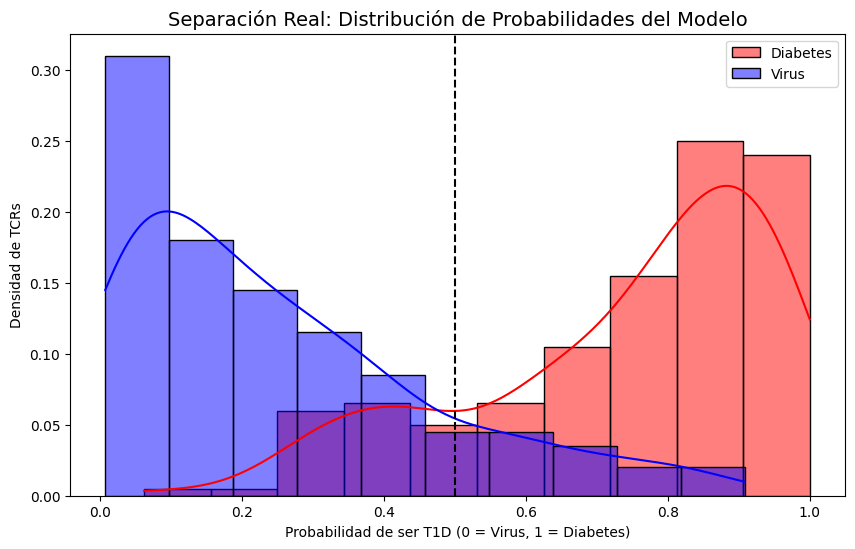

In [140]:
# 1. Obtener probabilidades del modelo ganador (LASSO) sobre todo el dataset
# Check if best_clf is a pipeline and extract the lasso model and scaler if applicable
if isinstance(best_clf, Pipeline) and 'lasso' in best_clf.named_steps:
    lasso_model = best_clf.named_steps['lasso']
    # If the scaler was part of the best_clf pipeline, use it
    if 'scaler' in best_clf.named_steps:
        scaler = best_clf.named_steps['scaler']
        probs = lasso_model.predict_proba(scaler.transform(X))[:, 1]
    else:
        probs = lasso_model.predict_proba(X)[:, 1] # Fallback if no scaler in pipeline
elif best_clf is not None: # If best_clf is a standalone model
    probs = best_clf.predict_proba(X)[:, 1]
else:
    print("No best classifier found or it's not a recognized type for prediction.")
    probs = np.array([]) # Default to empty array to prevent further errors

# 2. Graficar las "Dos Montañas"
plt.figure(figsize=(10, 6))
# Ensure df_final is accessible and has 'label'
if not df_final.empty and 'label' in df_final.columns:
    sns.histplot(probs[df_final['label'] == 1], color="red", label="Diabetes", kde=True, stat="probability", alpha=0.5)
    sns.histplot(probs[df_final['label'] == 0], color="blue", label="Virus", kde=True, stat="probability", alpha=0.5)

    plt.axvline(0.5, color='black', linestyle='--')
    plt.title("Separación Real: Distribución de Probabilidades del Modelo", fontsize=14)
    plt.xlabel("Probabilidad de ser T1D (0 = Virus, 1 = Diabetes)")
    plt.ylabel("Densidad de TCRs")
    plt.legend()
    plt.show()
else:
    print("DataFrame 'df_final' is empty or 'label' column is missing, cannot plot.")

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Lista de familias para ocultar
familias = ['Insulin', 'GAD', 'ZnT8']

print(f" EVALUANDO GENERALIZACIÓN DEL MODELO LASSO \n")

for target in familias:
    # Máscara para el antígeno a ocultar
    mask_target = df_final['Epitope gene'].str.contains(target, case=False, na=False)

    if mask_target.sum() == 0: continue

    # Índices: Test (Antígeno oculto + Virus) | Train (Resto)
    idx_test_auto = df_final[mask_target].index
    idx_test_virus = df_final[df_final['label'] == 0].sample(len(idx_test_auto), random_state=42).index
    idx_test = np.concatenate([idx_test_auto, idx_test_virus])
    idx_train = df_final.index.difference(idx_test)

    # Escalado (Obligatorio para LASSO)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X[idx_train])
    X_test_sc = scaler.transform(X[idx_test])

    # Modelo LASSO (Configuración ganadora)
    # penalty='l1' es lo que lo hace LASSO
    lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, class_weight='balanced')
    lasso_model.fit(X_train_sc, df_final.loc[idx_train, 'label'])

    # Evaluación
    probs = lasso_model.predict_proba(X_test_sc)[:, 1]
    auc_loao = roc_auc_score(df_final.loc[idx_test, 'label'], probs)

    print(f"Ocultando {target:10} | AUC en datos nunca vistos: {auc_loao:.4f}")

 EVALUANDO GENERALIZACIÓN DEL MODELO LASSO 

Ocultando Insulin    | AUC en datos nunca vistos: 0.5000
Ocultando GAD        | AUC en datos nunca vistos: 0.7863
Ocultando ZnT8       | AUC en datos nunca vistos: 0.7237


EXTERNAL VALIDATION SET mcPAS-TCR

In [142]:
df_auto_mcPAS = pd.read_csv(path_auto_tcr_mcPAS, sep=',')

In [143]:
df_auto_mcPAS.head()

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,CAANRGGYGYTF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,aataatctatttctcatatgatgttaaaatgaaagaaaaaggagat...,NaN,29176645,NaN
1,NaN,CAASGGSNYKLTF,Human,Autoimmune,Diabetes Type 1,D003922,NaN,1.0,Yes,Yes,...,NaN,NaN,TRBV29/DV5:01,NaN,TRBJ53:01,No,NaN,NaN,28300170,NaN
2,CATAIISNFGNEKLTF,CAASPLSGSARQLTF,Human,Autoimmune,Diabetes Type 1,D003922,NaN,1.0,Yes,Yes,...,TRAV29/DV5,TRAJ22,TRBV18,NaN,TRBJ1-3,No,NaN,NaN,27920090,NaN
3,NaN,CAAYSFGRGGGTEAFF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,ttctcattgatgttaaaatgaaagaaaaaggagatattcctgaggg...,NaN,29176645,NaN
4,NaN,CACSDDCYKQYF,Human,Autoimmune,Diabetes Type 1,D003947,NaN,2.1,No,Yes,...,NaN,NaN,NaN,NaN,NaN,No,aatattcgatgatcaattctcagttgaaaggcctgatggatcaaat...,NaN,29176645,NaN


In [144]:
df_filtered_auto_mcPAS =df_auto_mcPAS.dropna(subset=['CDR3.alpha.aa', 'CDR3.beta.aa'])[['CDR3.alpha.aa', 'CDR3.beta.aa', 'Antigen.protein']]

In [145]:
df_filtered_auto_mcPAS.shape

(290, 3)

In [146]:
n_alpha = df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_auto['CDR3']).sum()
n_beta  = df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_auto['CDR3']).sum()

print(f"Matches in alpha: {n_alpha}")
print(f"Matches in beta:  {n_beta}")

Matches in alpha: 16
Matches in beta:  8


In [147]:
df_filtered_auto_mcPAS = df_filtered_auto_mcPAS[
    ~df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_auto['CDR3']) &
    ~df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_auto['CDR3'])
]

In [148]:
df_filtered_auto_mcPAS.shape

(272, 3)

In [149]:
df_filtered_auto_mcPAS = df_filtered_auto_mcPAS[
    ~df_filtered_auto_mcPAS['CDR3.alpha.aa'].isin(df_virus['CDR3']) &
    ~df_filtered_auto_mcPAS['CDR3.beta.aa'].isin(df_virus['CDR3'])
]

In [150]:
df_filtered_auto_mcPAS.shape

(266, 3)

In [151]:

col_alpha = 'CDR3.alpha.aa'
col_beta = 'CDR3.beta.aa'

df_filtered_auto_mcPAS['esm_input'] = (
    df_filtered_auto_mcPAS[col_alpha].astype(str) + ":" +
    df_filtered_auto_mcPAS[col_beta].astype(str)
)

print(f"Extracting embeddings from {len(df_filtered_auto_mcPAS)} sequences from McPAS...")
X_mcpas_auto = extract_esm_embeddings(df_filtered_auto_mcPAS['esm_input'].tolist())

virus_pool = df_virus_strict[~df_virus_strict['CDR3'].isin(df_final['esm_input'])]

v_alphas = virus_pool[virus_pool['Gene'] == 'TRA'].reset_index(drop=True)
v_betas = virus_pool[virus_pool['Gene'] == 'TRB'].reset_index(drop=True)

# Tomamos exactamente la misma cantidad que el df de McPAS
n_size = len(df_filtered_auto_mcPAS)

virus_inputs = [
    f"{v_alphas.loc[i, 'CDR3']}:{v_betas.loc[i, 'CDR3']}"
    for i in range(n_size)
]

print(f"Extrayendo embeddings de {n_size} secuencias de Virus nuevas...")
X_mcpas_virus = extract_esm_embeddings(virus_inputs)

# 3. Concatenar y crear etiquetas (Labels)
# Stack vertical de las matrices de embeddings
X_external = np.vstack([X_mcpas_auto, X_mcpas_virus])

# Etiquetas: 1 para McPAS (Diabetes), 0 para Virus
y_external = np.array([1] * n_size + [0] * n_size)

print(f"X_external shape: {X_external.shape} | Labels: {len(y_external)}")

Extracting embeddings from 266 sequences from McPAS...
 usando dispositivo: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extrayendo Embeddings: 100%|██████████| 9/9 [00:00<00:00, 17.05it/s]


Extrayendo embeddings de 266 secuencias de Virus nuevas...
 usando dispositivo: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extrayendo Embeddings: 100%|██████████| 9/9 [00:01<00:00,  8.30it/s]

X_external shape: (532, 320) | Labels: 532


In [152]:

X_external_scaled = scaler.transform(X_external)

probs_ext = best_clf.predict_proba(X_external_scaled)[:, 1]


from sklearn.metrics import roc_auc_score
auc_ext = roc_auc_score(y_external, probs_ext)

print(f"AUC en Validación Externa con Scaler correcto: {auc_ext:.4f}")

AUC en Validación Externa con Scaler correcto: 0.5387


In [153]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle

# --- 1. Preparar McPAS sin filtros de antígeno ---
# Simplemente nos aseguramos de que tengan Alpha y Beta
df_mcpas_all = df_filtered_auto_mcPAS.copy()

df_mcpas_all['esm_input'] = (
    df_mcpas_all['CDR3.alpha.aa'].astype(str) + ":" +
    df_mcpas_all['CDR3.beta.aa'].astype(str)
)
df_mcpas_all['label'] = 1

# --- 2. Concatenar con tu entrenamiento previo (VDJdb) ---
# Usamos df_final que ya tiene los Virus y Diabetes de VDJdb balanceados
df_combined_raw = pd.concat([
    df_final[['esm_input', 'label']],
    df_mcpas_all[['esm_input', 'label']]
]).reset_index(drop=True)

# Mezclar para que el modelo no aprenda el orden de las bases de datos
df_combined_raw = shuffle(df_combined_raw, random_state=42).reset_index(drop=True)

print(f"Dataset Híbrido Creado: {len(df_combined_raw)} secuencias.")
print("Distribución de clases:\n", df_combined_raw['label'].value_counts())

Dataset Híbrido Creado: 666 secuencias.
Distribución de clases:
 label
1    466
0    200
Name: count, dtype: int64


In [154]:
# 1. Identificar virus que NO hemos usado todavía en ningún set
virus_usados = df_final[df_final['label'] == 0]['esm_input'].tolist()
virus_disponibles = df_virus[~df_virus['CDR3'].isin(virus_usados)]

# 2. Separar Alphas y Betas para crear pares nuevos (fuerza bruta)
v_alphas_pool = virus_disponibles[virus_disponibles['Gene'] == 'TRA'].reset_index(drop=True)
v_betas_pool = virus_disponibles[virus_disponibles['Gene'] == 'TRB'].reset_index(drop=True)

# 3. Crear 266 pares nuevos
n_needed = 266
virus_nuevos_list = [
    f"{v_alphas_pool.loc[i, 'CDR3']}:{v_betas_pool.loc[i, 'CDR3']}"
    for i in range(n_needed)
]

# 4. Crear el DataFrame de estos nuevos virus
df_virus_extra = pd.DataFrame({
    'esm_input': virus_nuevos_list,
    'label': 0
})

# 5. Unir al dataset híbrido anterior
df_final_maestro = pd.concat([df_combined_raw, df_virus_extra]).reset_index(drop=True)
df_final_maestro = shuffle(df_final_maestro, random_state=42).reset_index(drop=True)

print("Dataset Maestro Balanceado:")
print(df_final_maestro['label'].value_counts())
print(f"Total: {len(df_final_maestro)} secuencias (466 de cada clase)")

Dataset Maestro Balanceado:
label
0    466
1    466
Name: count, dtype: int64
Total: 932 secuencias (466 de cada clase)


In [155]:
# 1. Extraer embeddings (esto tardará un poquito más, son 932 secuencias en total)
print("Generando embeddings para el Dataset Maestro...")
X_maestro = extract_esm_embeddings(df_final_maestro['esm_input'].tolist())
y_maestro = df_final_maestro['label'].values

# 2. ¡A la batalla de modelos!
# Aquí es donde veremos si el LASSO es capaz de generalizar VDJdb + McPAS
resultados_maestro, best_clf_maestro, scaler_maestro = big_model_battle(X_maestro, y_maestro)

Generando embeddings para el Dataset Maestro...
 usando dispositivo: cuda


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extrayendo Embeddings: 100%|██████████| 30/30 [00:02<00:00, 11.45it/s]


MODEL BATTLE

Random Forest        -> AUC: 0.7412
SVM (RBF)            -> AUC: 0.7632
Logit (Normal)       -> AUC: 0.7947
Logit (LASSO L1)     -> AUC: 0.7867 (Usó 123 dimensiones)
XGBoost              -> AUC: 0.7609


<Figure size 800x600 with 0 Axes>

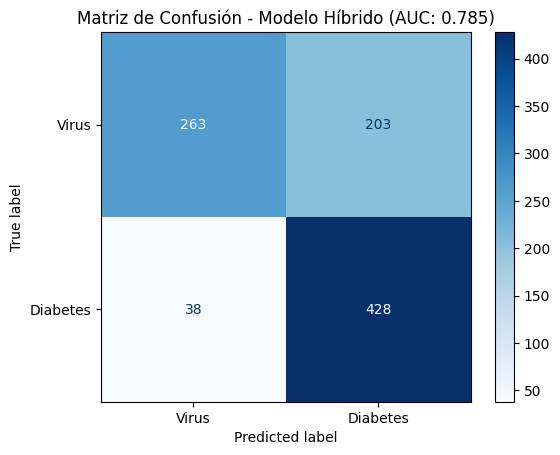

In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predecir etiquetas (no solo probabilidades)
y_pred = best_clf_maestro.predict(scaler_maestro.transform(X_maestro))

# 2. Crear la matriz
cm = confusion_matrix(y_maestro, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Virus', 'Diabetes'])

# 3. Plotear
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matriz de Confusión - Modelo Híbrido (AUC: {0.7850})")
plt.show()

In [167]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_clf, X_maestro, y_maestro, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.7588 (+/- 0.0371)


DIFFERENCE WITH BLOSUM62

In [160]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.0 MB/s eta 0:00:00


In [163]:
from Bio.Align import substitution_matrices
import numpy as np

blosum50 = substitution_matrices.load("BLOSUM50")
amino_acids = "ARNDCQEGHILKMFPSTWYV" # Los 20 estándar

def get_blosum50_vector(sequence, max_len=30):
    """Convierte una proteína en un vector plano usando BLOSUM50"""
    # Truncar o rellenar (Padding) para que todos tengan el mismo tamaño
    sequence = sequence.replace(":", "") # Quitamos el separador para el encoding lineal
    seq = sequence[:max_len].ljust(max_len, '*') # '*' será nuestro padding

    encoding = []
    for aa in seq:
        if aa in amino_acids:
            # Extraemos la fila de la matriz para ese aminoácido (20 valores)
            row = [blosum50[aa][target] for target in amino_acids]
        else:
            # Para padding o caracteres extraños, usamos ceros
            row = [0] * 20
        encoding.extend(row)

    return np.array(encoding)


print("Generando vectores BLOSUM50...")
X_blosum = np.array([get_blosum50_vector(s) for s in df_final_maestro['esm_input']])
y_maestro = df_final_maestro['label'].values




Generando vectores BLOSUM50...


In [164]:
resultados_blosum, best_clf_blosum, scaler_blosum = big_model_battle(X_blosum, y_maestro)

MODEL BATTLE

Random Forest        -> AUC: 0.8181
SVM (RBF)            -> AUC: 0.8168
Logit (Normal)       -> AUC: 0.7205
Logit (LASSO L1)     -> AUC: 0.7656 (Usó 260 dimensiones)
XGBoost              -> AUC: 0.8065


In [166]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_clf_blosum, X_blosum, y_maestro, cv=10, scoring='roc_auc')
print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean AUC: 0.7911 (+/- 0.0258)



# Biological Interpretation and Final Conclusions

## Dataset balancing strategy

The original dataset contained an imbalance between classes:
- Autoimmune / diabetes-associated TCRs
- Virus-specific TCRs

To prevent the classifier from learning a trivial bias toward the
majority class, the dataset was balanced. Additional synthetic
virus pairs were generated by combining available TRA and TRB chains.
This produced a final balanced dataset of approximately equal size
per class.

Balancing the dataset is essential for reliable evaluation because
machine learning models tend to favor the majority class otherwise.

## Machine learning implications

By training on a balanced dataset:
- The classifier must learn sequence patterns rather than dataset bias.
- Evaluation metrics such as ROC-AUC become more meaningful.
- The model better reflects its potential biological generalization.

## Biological interpretation

If the trained model achieves strong performance, this suggests that
autoreactive TCRs may contain detectable sequence-level signatures
within their CDR3 regions.

These patterns may relate to:
- biochemical properties of residues
- structural constraints for peptide-MHC binding
- differences in repertoire selection.

However, several limitations must be acknowledged.

## Limitations

1. TCR recognition is highly context dependent and also influenced
   by V/J gene usage and structural interactions.
2. Sequence embeddings capture statistical patterns but not full
   structural binding mechanisms.
3. Synthetic pairing of alpha and beta chains may introduce
   combinations not naturally observed in vivo.

## Future improvements

Future work could significantly improve the predictive framework:

- Use larger immune repertoire datasets.
- Apply transformer-based deep learning models.
- Integrate structural modeling of TCR–pMHC interactions.
- Include V/J gene usage and physicochemical descriptors.

## Final perspective

Despite these limitations, this pipeline demonstrates how modern
protein language models combined with machine learning can help
identify signals of autoreactivity in TCR repertoires. Such tools
may contribute to improved understanding of autoimmune diseases
and immune repertoire profiling in the future.
